## Задание

Распознайте рукописную цифру, написанную на листе от руки.
Последовательность шагов следующая:

*   На бумаге рисуем произвольную цифру (желательно нарисовать цифру размером не
более 5 * 5 мм и без наклона. В занятии нейронка обучалась на цифрах американских студентов. Эти цифры были написаны на тетрадных листах в клетку и имели схожий размер).
*   Фотографируем. Загружаем фото в Collaboratory.
*   С помощью функции image.load_img(path, target_size=(28, 28), color_mode = ‘grayscale’) загружаем картинку в переменную.
*   С помощью функции image.img_to_array(img) преобразуем изображение в numpy-массив.
*   Выполняем инверсию цветов, нормирование и решейп массива.
*   Выполняем распознавание собственной рукописной цифры.

Примечание: точность распознавания рукописных цифр может быть достаточно низкой, т.к. рукописные цифры после преобразований хоть и похожи на содержащиеся в базе, но могут отличаться по конфигурации, толщине линий и т.д.


In [189]:
# Ваше решение
import os
from tensorflow.keras.datasets import mnist     # Библиотека с базой рукописных цифр
from tensorflow.keras.models import Sequential  # Подключение класса создания модели Sequential
from tensorflow.keras.layers import Dense       # Подключение класса Dense - полносвязный слой
from tensorflow.keras import utils              # Утилиты для подготовки данных
import numpy as np                              # Работа с массивами
import matplotlib.pyplot as plt                 # Отрисовка изображений
from tensorflow.keras.preprocessing import image
# Отрисовка изображений в ячейках ноутбука
%matplotlib inline

In [190]:
import gdown
gdown.download('https://drive.google.com/file/d/1tWCKsWuh2plheNg27MH7IR0NBy64w5tL/view?usp=sharing', None, quiet=True, fuzzy=True)

'test_images.zip'

In [191]:
!unzip -oq test_images.zip

In [192]:
!ls

sample_data  test_images  test_images.zip


In [193]:
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [194]:
x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

# Проверка результата
print(f'Форма обучающих данных: {x_train_org.shape} -> {x_train.shape}')
print(f'Форма  тестовых данных: {x_test_org.shape} -> {x_test.shape}')

Форма обучающих данных: (60000, 28, 28) -> (60000, 784)
Форма  тестовых данных: (10000, 28, 28) -> (10000, 784)


In [195]:
# Преобразование x_train в тип float32 (числа с плавающей точкой) и нормализация
x_train = x_train.astype('float32') / 255.

# Преобразование x_test в тип float32 (числа с плавающей точкой) и нормализация
x_test = x_test.astype('float32') / 255.

In [196]:
CLASS_COUNT = 10

In [197]:
# Преобразование ответов в формат one_hot_encoding
y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

In [198]:
model = Sequential()

# Добавление полносвязного слоя на 800 нейронов с relu-активацией
model.add(Dense(256, input_dim=784, activation='relu'))

# Добавление полносвязного слоя на 400 нейронов с relu-активацией
model.add(Dense(128, activation='relu'))

# Добавление полносвязного слоя с количеством нейронов по числу классов с softmax-активацией
model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Вывод структуры модели
print(model.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [199]:
model.fit(x_train,        # обучающая выборка, входные данные
          y_train,        # обучающая выборка, выходные данные
          batch_size=256, # кол-во примеров, которое обрабатывает нейронка перед одним изменением весов
          epochs=5,      # количество эпох, когда нейронка обучается на всех примерах выборки
          verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9054 - loss: 0.3352
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9631 - loss: 0.1260
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9753 - loss: 0.0838
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9821 - loss: 0.0594
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9858 - loss: 0.0463


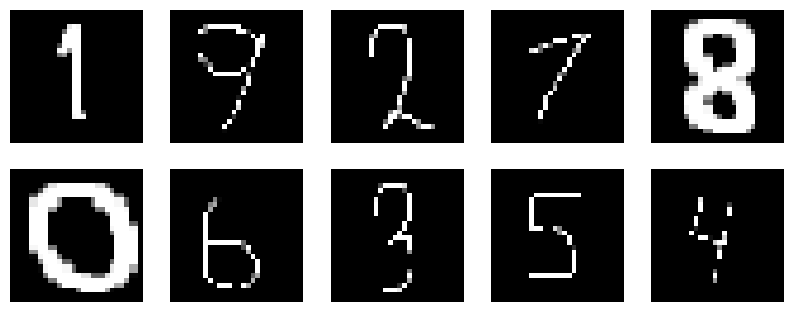

In [200]:
files = os.listdir('test_images')

plt.figure(figsize=(10,10))

for i, file in enumerate(files):
    img = image.load_img(f'test_images/{file}', target_size=(28,28), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = 1 - img_array

    plt.subplot(5,5,i+1)
    plt.imshow(img_array.reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()


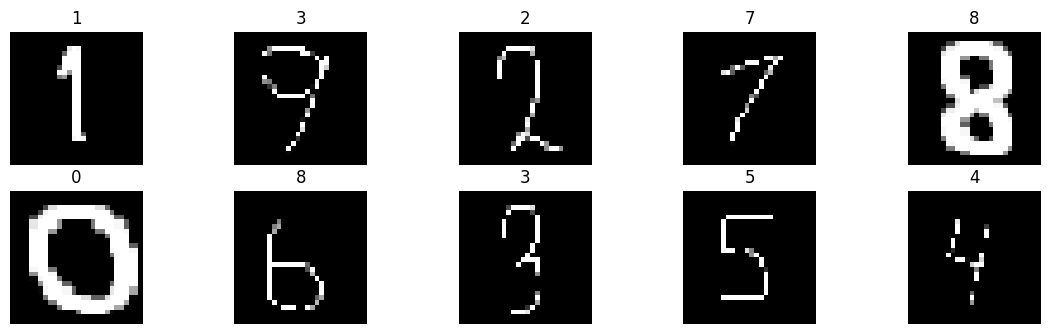

In [210]:
files = os.listdir('test_images')

plt.figure(figsize=(14,10))

for i, file in enumerate(files):
    img = image.load_img(f'test_images/{file}', target_size=(28,28), color_mode='grayscale')
    img_array = image.img_to_array(img) / 255.0
    img_array = 1 - img_array

    img_model = np.expand_dims(img_array, axis=0)
    img_model = img_model.reshape(1, 784)

    prediction = model.predict(img_model, verbose=0)
    digit = np.argmax(prediction)

    plt.subplot(5,5,i+1)
    plt.imshow(img_array.reshape(28,28), cmap='gray')
    plt.title(f"{digit}")
    plt.axis('off')

plt.show()